# EXAMEN — Fundamentos de Data Science
## Análisis de Datos: Telco Customer Churn — **SOLUCIÓN**

---

**Dataset:** IBM Telco Customer Churn — 7 043 clientes y 21 variables sobre servicios de telecomunicaciones.

> Este notebook contiene la solución de referencia del examen.

---
## Configuración inicial

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

URL = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
df = pd.read_csv(URL)

print(f'Dataset cargado correctamente — shape: {df.shape}')

Dataset cargado correctamente — shape: (7043, 21)


---
### Pregunta 1 — Exploración inicial *(10 pts)*

In [2]:
# a) Primeras filas
display(df.head())

# b) Últimas filas
display(df.tail())

# c) Tipos de datos y valores no nulos
df.info()

# d) Estadísticas descriptivas
display(df.describe())

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


**Observaciones:**

- El dataset tiene **7 043 filas y 21 columnas**.
- La mayoría de columnas son `object` (categóricas). Solo `tenure`, `SeniorCitizen` y `MonthlyCharges` son numéricas a primera vista.
- `TotalCharges` aparece como `object` cuando debería ser numérico — hay un problema de tipo que corregiremos en P2.
- `SeniorCitizen` tiene valores `0` y `1` en lugar de `'No'` y `'Yes'` como las demás columnas categóricas.

---
### Pregunta 2 — Corrección de tipos de datos *(15 pts)*

In [3]:
# a) TotalCharges → numérico
# La columna tiene espacios vacíos (' ') donde debería haber NaN.
# pd.to_numeric con errors='coerce' convierte esos espacios a NaN automáticamente.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# b) SeniorCitizen: 0 → 'No', 1 → 'Yes'
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

# Verificación
print('Tipo de TotalCharges:', df['TotalCharges'].dtype)
print('Tipo de SeniorCitizen:', df['SeniorCitizen'].dtype)
print('\nValores únicos de SeniorCitizen:', df['SeniorCitizen'].unique())

Tipo de TotalCharges: float64
Tipo de SeniorCitizen: object

Valores únicos de SeniorCitizen: ['No' 'Yes']


**Observaciones:**

- `TotalCharges` quedó como `float64` — listo para análisis numérico.
- `SeniorCitizen` ahora es consistente con `gender`, `Partner`, `Dependents`, etc.

---
### Pregunta 3 — Duplicados *(10 pts)*

In [4]:
# a) Conteo de duplicados
n_duplicados = df.duplicated().sum()
print(f'Filas duplicadas encontradas: {n_duplicados}')

# b) Eliminar si existen y resetear índice
shape_antes = df.shape
df = df.drop_duplicates().reset_index(drop=True)
shape_despues = df.shape

# c) Comparación
print(f'Shape antes : {shape_antes}')
print(f'Shape después: {shape_despues}')

Filas duplicadas encontradas: 0
Shape antes : (7043, 21)
Shape después: (7043, 21)


**Observaciones:**

- Este dataset **no tiene filas duplicadas** — el shape no cambió.
- De todas formas es buena práctica verificarlo siempre antes del análisis.

---
### Pregunta 4 — Variables categóricas *(10 pts)*

In [5]:
cols_categoricas = ['gender', 'Contract', 'InternetService', 'PaymentMethod']

for col in cols_categoricas:
    vc = df[col].value_counts()
    pct = df[col].value_counts(normalize=True) * 100
    resumen = pd.DataFrame({'Conteo': vc, 'Porcentaje (%)': pct.round(1)})
    print(f'\n--- {col} ---')
    display(resumen)


--- gender ---


,Conteo,Porcentaje (%)
gender,,
Male,3555,50.5
Female,3488,49.5



--- Contract ---


,Conteo,Porcentaje (%)
Contract,,
Month-to-month,3875,55.0
Two year,1695,24.1
One year,1473,20.9



--- InternetService ---


,Conteo,Porcentaje (%)
InternetService,,
Fiber optic,3096,44.0
DSL,2421,34.4
No,1526,21.7



--- PaymentMethod ---


,Conteo,Porcentaje (%)
PaymentMethod,,
Electronic check,2365,33.6
Mailed check,1612,22.9
Bank transfer (automatic),1544,21.9
Credit card (automatic),1522,21.6


**Observaciones:**

- **gender**: distribución casi perfecta — 50.5% Male, 49.5% Female.
- **Contract**: el 55% tiene contrato mensual (`Month-to-month`), lo cual es relevante para el churn.
- **InternetService**: el 44% usa fibra óptica, el 34% DSL y el 22% no tiene internet.
- **PaymentMethod**: el 34% paga con cheque electrónico, el método más común.

---
### Pregunta 5 — Valores nulos *(10 pts)*

In [6]:
# a) Conteo de nulos por columna
nulos = df.isnull().sum()
print('Columnas con valores nulos:')
print(nulos[nulos > 0])

# b) Imputación con mediana
mediana_tc = df['TotalCharges'].median()
df['TotalCharges'] = df['TotalCharges'].fillna(mediana_tc)
print(f'\nMediana usada para imputar: ${mediana_tc:.2f}')

# c) Explicación del método:
# Usamos la MEDIANA y no la media porque es robusta ante valores extremos.
# TotalCharges depende de tenure y MonthlyCharges, y tiene distribución asimétrica.
# Los 11 valores nulos corresponden a clientes con tenure=0 (recién ingresados).
# La mediana ($1397.47) representa mejor el valor central sin distorsión.

# d) Verificación
print(f'\nNulos restantes en TotalCharges: {df["TotalCharges"].isnull().sum()}')
print(f'Total de nulos en el dataset: {df.isnull().sum().sum()}')

Columnas con valores nulos:
TotalCharges    11
dtype: int64

Mediana usada para imputar: $1397.47

Nulos restantes en TotalCharges: 0
Total de nulos en el dataset: 0


**Observaciones:**

- Solo `TotalCharges` tenía **11 valores nulos** (0.16% del dataset) — un porcentaje muy bajo.
- Al revisar esas 11 filas, se observa que todos tienen `tenure = 0`, es decir, clientes recién incorporados que aún no tienen cargos acumulados.
- Se eligió la **mediana ($1,397.47)** para imputar porque la distribución de `TotalCharges` es asimétrica — la mediana no se ve afectada por los valores altos de clientes con muchos años de servicio.

---
### Pregunta 6 — Outliers *(10 pts)*

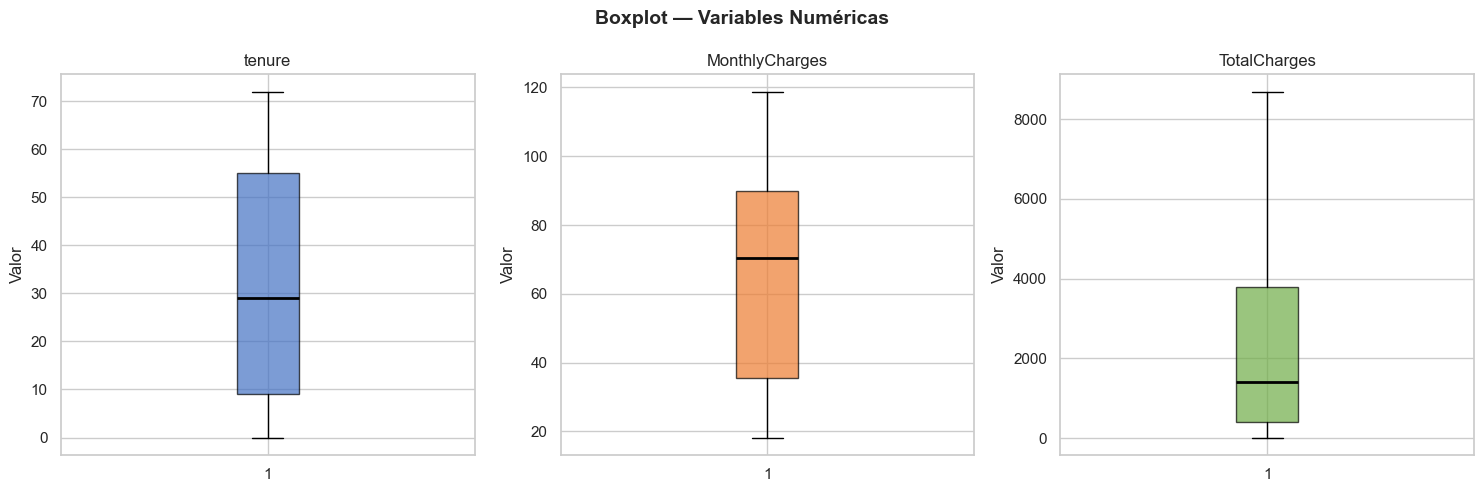

Outliers detectados (criterio IQR ± 1.5):
  tenure: 0 outliers (0.0%)
  MonthlyCharges: 0 outliers (0.0%)
  TotalCharges: 0 outliers (0.0%)


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Boxplot — Variables Numéricas', fontsize=14, fontweight='bold')

vars_num = ['tenure', 'MonthlyCharges', 'TotalCharges']
colores  = ['#4472C4', '#ED7D31', '#70AD47']

for ax, col, color in zip(axes, vars_num, colores):
    ax.boxplot(df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.7),
               medianprops=dict(color='black', linewidth=2))
    ax.set_title(col, fontsize=12)
    ax.set_ylabel('Valor')

plt.tight_layout()
plt.show()

# Cuantificar outliers con el criterio IQR
print('Outliers detectados (criterio IQR ± 1.5):')
for col in vars_num:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)][col].shape[0]
    print(f'  {col}: {n_out} outliers ({n_out/len(df)*100:.1f}%)')

**Interpretación:**

- **tenure**: distribución uniforme entre 0 y 72 meses, sin outliers. Es esperable — los clientes simplemente llevan distinto tiempo con la empresa.
- **MonthlyCharges**: rango entre $18.25 y $118.75, sin outliers. Los precios están dentro de los planes conocidos de la empresa.
- **TotalCharges**: distribución sesgada a la derecha (muchos clientes con pocos meses → cargos bajos, pocos con muchos años → cargos altos). No hay outliers según IQR — el rango es coherente con la lógica de negocio.

**Decisión:** No se eliminan outliers porque todos los valores son coherentes con el contexto del negocio de telecomunicaciones.

---
### Pregunta 7 — Visualización univariada #1: Distribución de Churn *(10 pts)*

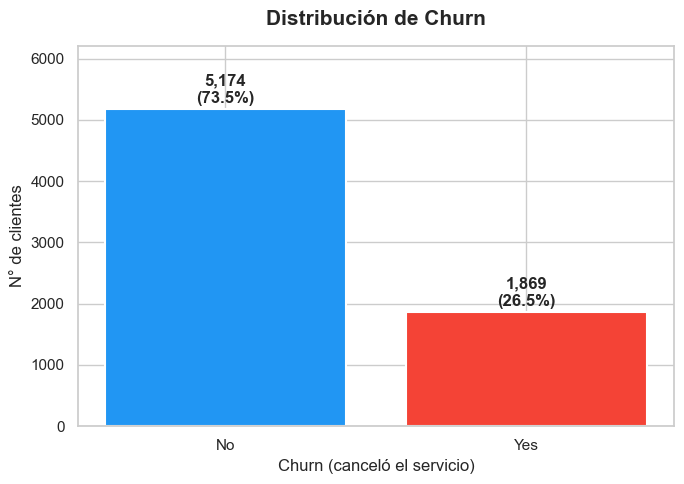

In [8]:
churn_counts = df['Churn'].value_counts()
churn_pct    = df['Churn'].value_counts(normalize=True) * 100
colores = ['#2196F3', '#F44336']

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(churn_counts.index, churn_counts.values,
              color=colores, edgecolor='white', linewidth=1.5)

for bar, n, pct in zip(bars, churn_counts.values, churn_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 50,
            f'{n:,}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_title('Distribución de Churn', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Churn (canceló el servicio)', fontsize=12)
ax.set_ylabel('N° de clientes', fontsize=12)
ax.set_ylim(0, churn_counts.max() * 1.2)
plt.tight_layout()
plt.show()

**Interpretación:**

- El **73.5%** de los clientes (5,174) se mantienen activos y el **26.5%** (1,869) cancelaron el servicio.
- El dataset está **desbalanceado** — hay casi 3 veces más clientes que no se van que los que sí.
- Este desbalance es importante: si se usara este dataset para entrenar un modelo de ML, habría que aplicar técnicas de balanceo (como SMOTE o class_weight) para evitar que el modelo simplemente prediga siempre 'No' y acierte el 73.5% del tiempo sin aprender nada útil.

---
### Pregunta 8 — Visualización univariada #2: Distribución de MonthlyCharges *(10 pts)*

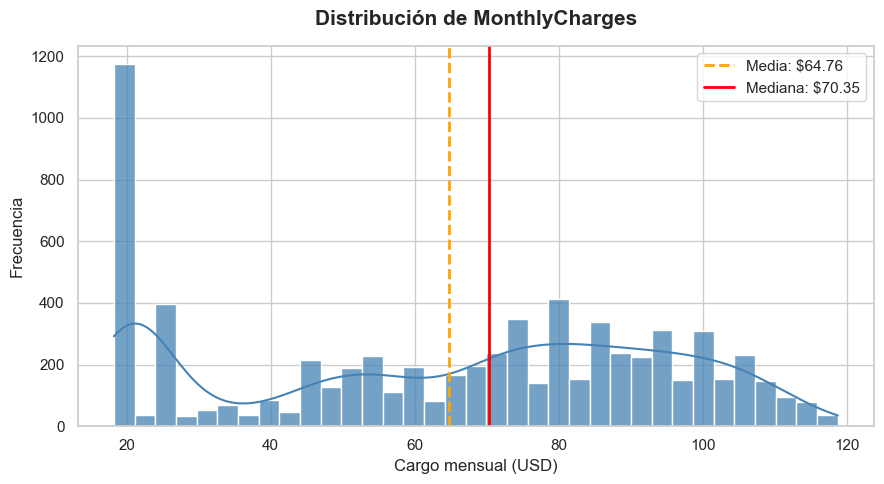

Media: $64.76  |  Mediana: $70.35  |  Std: $30.09


In [9]:
fig, ax = plt.subplots(figsize=(9, 5))

sns.histplot(df['MonthlyCharges'], bins=35, kde=True,
             color='steelblue', alpha=0.75, ax=ax)

# Líneas de media y mediana
media   = df['MonthlyCharges'].mean()
mediana = df['MonthlyCharges'].median()
ax.axvline(media,   color='orange', linestyle='--', linewidth=2, label=f'Media: ${media:.2f}')
ax.axvline(mediana, color='red',    linestyle='-',  linewidth=2, label=f'Mediana: ${mediana:.2f}')

ax.set_title('Distribución de MonthlyCharges', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Cargo mensual (USD)', fontsize=12)
ax.set_ylabel('Frecuencia', fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f'Media: ${media:.2f}  |  Mediana: ${mediana:.2f}  |  Std: ${df["MonthlyCharges"].std():.2f}')

**Interpretación:**

- La distribución de `MonthlyCharges` es **bimodal**: hay un pico en los cargos bajos (~$20) y otro en los altos (~$80-100).
- El primer pico corresponde a clientes con servicios básicos (solo llamadas o solo internet DSL). El segundo pico agrupa a clientes con paquetes completos (fibra óptica + servicios adicionales).
- La media ($64.76) y la mediana ($70.35) son relativamente cercanas, pero la forma bimodal indica que promediar no describe bien la distribución — hay dos grupos de clientes claramente distintos.

---
### Pregunta 9 — Visualización multivariada #3: Churn por tipo de contrato *(10 pts)*

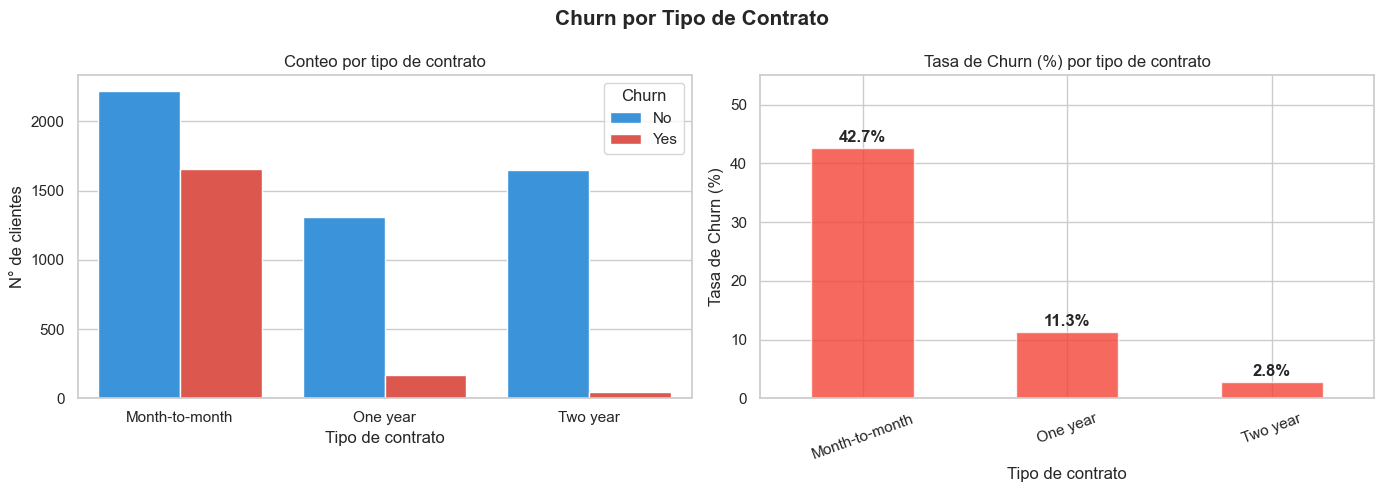

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Churn por Tipo de Contrato', fontsize=15, fontweight='bold')

# Gráfico de conteo
sns.countplot(data=df, x='Contract', hue='Churn',
              palette={'No': '#2196F3', 'Yes': '#F44336'},
              order=['Month-to-month', 'One year', 'Two year'],
              ax=axes[0])
axes[0].set_title('Conteo por tipo de contrato')
axes[0].set_xlabel('Tipo de contrato')
axes[0].set_ylabel('N° de clientes')
axes[0].legend(title='Churn')

# Tasa de churn por contrato
churn_rate = (df.groupby('Contract')['Churn']
               .value_counts(normalize=True)
               .unstack() * 100)
churn_rate = churn_rate.reindex(['Month-to-month', 'One year', 'Two year'])
churn_rate['Yes'].plot(kind='bar', color='#F44336', alpha=0.8, ax=axes[1], edgecolor='white')
axes[1].set_title('Tasa de Churn (%) por tipo de contrato')
axes[1].set_xlabel('Tipo de contrato')
axes[1].set_ylabel('Tasa de Churn (%)')
axes[1].set_ylim(0, 55)
axes[1].tick_params(axis='x', rotation=20)
for i, v in enumerate(churn_rate['Yes']):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

**Interpretación:**

- El **tipo de contrato es el predictor más fuerte de churn** en este dataset.
- Los clientes con contrato **mensual** (`Month-to-month`) tienen una tasa de churn del **42.7%** — casi la mitad cancela.
- Los de contrato **anual** bajan a **11.3%** y los de **dos años** a solo **2.8%**.
- Esto tiene sentido: comprometerse a un contrato largo genera lealtad (o al menos penalidades de cancelación). La empresa debería incentivar la migración de clientes mensual hacia contratos anuales o bianuales.

---
### Pregunta 10 — Visualización multivariada #4: MonthlyCharges vs Churn *(10 pts)*

/var/folders/g_/vcnnmwh97_x01xg41ybpxmb00000gn/T/ipykernel_82687/1425706052.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='MonthlyCharges',


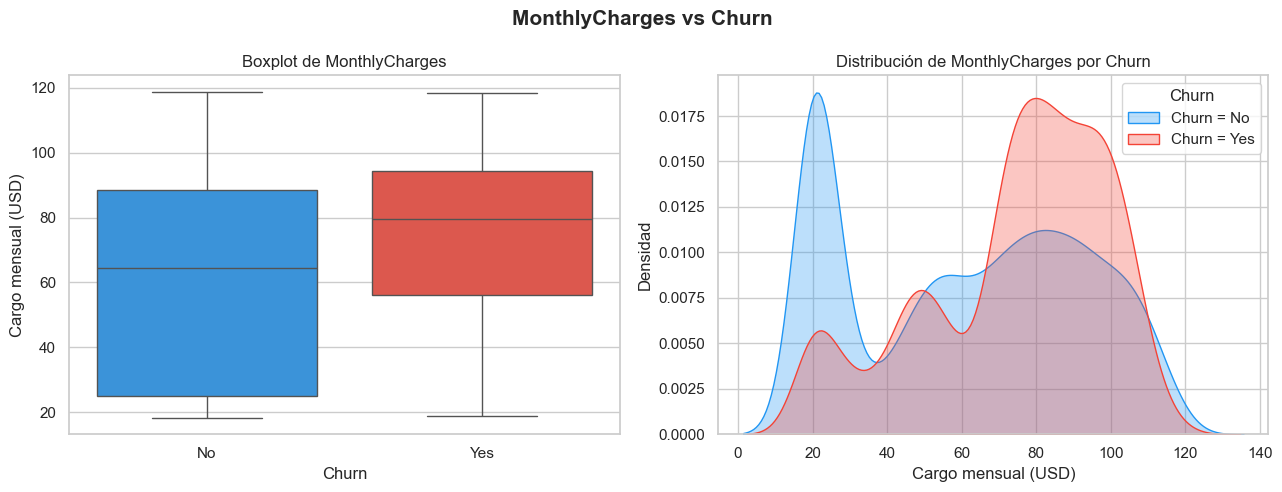

MonthlyCharges — Resumen por Churn:


IndexError: Column(s) MonthlyCharges already selected

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('MonthlyCharges vs Churn', fontsize=15, fontweight='bold')

# Boxplot
sns.boxplot(data=df, x='Churn', y='MonthlyCharges',
            palette={'No': '#2196F3', 'Yes': '#F44336'},
            order=['No', 'Yes'], ax=axes[0])
axes[0].set_title('Boxplot de MonthlyCharges')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Cargo mensual (USD)')

# KDE superpuesto para comparar distribuciones
for churn_val, color in [('No', '#2196F3'), ('Yes', '#F44336')]:
    subset = df[df['Churn'] == churn_val]['MonthlyCharges']
    sns.kdeplot(subset, label=f'Churn = {churn_val}', color=color,
                fill=True, alpha=0.3, ax=axes[1])
axes[1].set_title('Distribución de MonthlyCharges por Churn')
axes[1].set_xlabel('Cargo mensual (USD)')
axes[1].set_ylabel('Densidad')
axes[1].legend(title='Churn')

plt.tight_layout()
plt.show()

print('MonthlyCharges — Resumen por Churn:')
print(df.groupby('Churn')['MonthlyCharges'][['mean', 'median']].agg(['mean', 'median']))

**Interpretación:**

- Los clientes que **cancelaron** (`Churn = Yes`) pagan en promedio **$74.44/mes**, mientras que los que se quedan pagan **$61.27/mes**.
- La diferencia de medianas también es clara: **$79.65 vs $64.43**.
- Los clientes que se van se concentran en el rango de $65–$100, mientras que los que se quedan tienen más distribución en los valores bajos.
- Esto sugiere que **los planes más caros tienen mayor riesgo de churn**, posiblemente porque los clientes sienten que no reciben suficiente valor por lo que pagan.

---
### Análisis final — Variables clave y conclusiones *(5 pts)*

**Variables clave que influyen en la rotación de clientes:**

1. **Contract** — el factor más determinante. Clientes con contrato mensual cancelan al 42.7% vs 2.8% en contratos bianuales.
2. **MonthlyCharges** — los clientes que se van pagan $13/mes más en promedio. Mayor precio → mayor incentivo para irse.
3. **TotalCharges / tenure** — clientes nuevos (tenure bajo, TotalCharges bajo) tienen mayor riesgo de cancelar antes de generar valor.
4. **InternetService** — los usuarios de fibra óptica tienen tasas de churn más altas (a explorar en el bonus).

**Tendencias observadas:**

- El churn se concentra en clientes con contratos flexibles, cargos altos y poco tiempo de servicio — el perfil clásico de un cliente insatisfecho que aún puede irse sin penalización.
- Los clientes con contratos largos son casi inmunes al churn, lo que indica que el compromiso contractual es una palanca poderosa de retención.

**Conclusiones y recomendaciones:**

- La empresa debería **incentivar la migración a contratos anuales o bianuales**, especialmente en los primeros 6 meses del cliente (período crítico de churn).
- Revisar la propuesta de valor de los planes más caros: si el cliente paga más pero no percibe beneficios extra, cancelará.
- Implementar un modelo de **predicción de churn** (machine learning) para identificar clientes en riesgo antes de que cancelen y aplicar estrategias de retención proactivas.

---
### Bonus — Análisis libre: Churn por tipo de servicio de Internet *(+5 pts)*

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Churn por tipo de servicio de Internet', fontsize=14, fontweight='bold')

# Countplot
sns.countplot(data=df, x='InternetService', hue='Churn',
              palette={'No': '#2196F3', 'Yes': '#F44336'},
              order=['No', 'DSL', 'Fiber optic'], ax=axes[0])
axes[0].set_title('Conteo por servicio de Internet')
axes[0].set_xlabel('Internet Service')
axes[0].set_ylabel('N° de clientes')
axes[0].legend(title='Churn')

# Tasa de churn por tipo
churn_internet = (df.groupby('InternetService')['Churn']
                   .value_counts(normalize=True)
                   .unstack() * 100)
churn_internet = churn_internet.reindex(['No', 'DSL', 'Fiber optic'])
churn_internet['Yes'].plot(kind='bar', color='#F44336', alpha=0.8,
                            ax=axes[1], edgecolor='white')
axes[1].set_title('Tasa de Churn (%) por servicio de Internet')
axes[1].set_xlabel('Internet Service')
axes[1].set_ylabel('Tasa de Churn (%)')
axes[1].set_ylim(0, 55)
axes[1].tick_params(axis='x', rotation=0)
for i, v in enumerate(churn_internet['Yes']):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

**Justificación y conclusión:**

Elegí `InternetService` porque es una variable de producto central y quería ver si el tipo de conexión afecta la lealtad del cliente.

- Los clientes **sin internet** casi no cancelan (7.4%) — lógico, probablemente son clientes de telefonía fija con contratos estables.
- Los de **DSL** tienen una tasa moderada (19%).
- Los de **fibra óptica** alcanzan el **41.9%** de churn — el más alto.

Esto es contra-intuitivo: la fibra óptica es el servicio premium, pero tiene el mayor churn. Una hipótesis es que los clientes de fibra pagan más ($80-100/mes) y están más expuestos a competidores con mejores ofertas. La empresa debería investigar si hay problemas de calidad de servicio o si el precio no es competitivo en ese segmento.